In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/US_2_2023.csv', low_memory=False)

print(df.shape)
print(df.columns.tolist())
print(df.head(3))

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/US_2_2023.csv'

In [ ]:
import os
print(os.getcwd())
print(os.listdir('../data/raw/'))




In [ ]:
print(os.listdir('../data/raw/'))

In [ ]:
df = pd.read_csv('../data/raw/2023_us.csv', low_memory=False)

print(df.shape)
print(df.columns.tolist())

In [3]:
import pandas as pd
import numpy as np

# Load all 4 years
years = [2020, 2021, 2022, 2023]
dfs = []

for year in years:
    temp = pd.read_csv(f'../data/raw/{year}_us.csv', low_memory=False)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print(f"Combined shape: {df.shape}")

# Rename key columns for easier use
df = df.rename(columns={
    '1. YEAR': 'year',
    '2. TRIFD': 'facility_id',
    '4. FACILITY NAME': 'facility_name',
    '8. ST': 'state',
    '12. LATITUDE': 'latitude',
    '13. LONGITUDE': 'longitude',
    '30. PRIMARY NAICS': 'naics',
    '23. INDUSTRY SECTOR': 'industry_sector',
    '119. PRODUCTION WSTE (8.1-8.7)': 'total_waste',
    '115. 8.4 - RECYCLING ON SITE': 'recycling_onsite',
    '116. 8.5 - RECYCLING OFF SIT': 'recycling_offsite',
    '113. 8.2 - ENERGY RECOVER ON': 'energy_recovery_onsite',
    '114. 8.3 - ENERGY RECOVER OF': 'energy_recovery_offsite',
    '107. TOTAL RELEASES': 'total_releases',
    '46. CARCINOGEN': 'carcinogen',
})

# Keep only columns we need
cols = ['year', 'facility_id', 'facility_name', 'state', 'latitude', 'longitude',
        'naics', 'industry_sector', 'total_waste', 'recycling_onsite',
        'recycling_offsite', 'energy_recovery_onsite', 'energy_recovery_offsite',
        'total_releases', 'carcinogen']

df = df[cols]

# Convert to numeric
num_cols = ['total_waste', 'recycling_onsite', 'recycling_offsite',
            'energy_recovery_onsite', 'energy_recovery_offsite', 'total_releases']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Feature engineering
df['total_diverted'] = (df['recycling_onsite'] + df['recycling_offsite'] +
                        df['energy_recovery_onsite'] + df['energy_recovery_offsite'])

df['diversion_rate'] = df['total_diverted'] / (df['total_waste'] + 1e-9)

# Target variable
df['at_risk'] = (df['diversion_rate'] < 0.90).astype(int)

print(df[['facility_name', 'diversion_rate', 'at_risk']].head(10))
print(f"\nAt-risk facilities: {df['at_risk'].sum()} / {len(df)}")

Combined shape: (315583, 122)
                                facility_name  diversion_rate  at_risk
0                    LINAMAR FORGING CAROLINA        0.999805        0
1                      WESTROCK SOUTHEAST LLC        0.000000        1
2                  ALPHA GENERAL SERVICES LLC        0.000000        1
3              MFG CHEMICAL INC CALLAHAN ROAD        0.000000        1
4  TOYOTA MOTOR MANUFACTURING MISSISSIPPI INC        0.777956        1
5                  COLETO CREEK POWER STATION        0.000000        1
6                            SENIOR FLEXONICS        0.989627        0
7   THE JANKOVICH CO PARAMOUNT FIXED FACILITY        0.000000        1
8                                   VALOR LLC        0.000000        1
9               CHEMICAL WASTE MANAGEMENT INC        0.000000        1

At-risk facilities: 252580 / 315583


In [4]:
# Aggregate to facility-year level
agg = df.groupby(['facility_id', 'facility_name', 'year', 'state', 
                   'latitude', 'longitude', 'naics', 'industry_sector']).agg(
    total_waste=('total_waste', 'sum'),
    total_diverted=('total_diverted', 'sum'),
    total_releases=('total_releases', 'sum'),
).reset_index()

# Recalculate diversion rate at facility level
agg['diversion_rate'] = agg['total_diverted'] / (agg['total_waste'] + 1e-9)
agg['at_risk'] = (agg['diversion_rate'] < 0.90).astype(int)

# Add log-transformed waste volume
agg['waste_volume_log'] = np.log1p(agg['total_waste'])

# Add diversion rate trend (year-over-year change per facility)
agg = agg.sort_values(['facility_id', 'year'])
agg['diversion_rate_trend'] = agg.groupby('facility_id')['diversion_rate'].diff().fillna(0)

print(agg.shape)
print(agg[['facility_name', 'year', 'diversion_rate', 'diversion_rate_trend', 'at_risk']].head(10))
print(f"\nAt-risk: {agg['at_risk'].sum()} / {len(agg)}")

(88093, 15)
                                       facility_name  year  diversion_rate  \
0                                     IDI CARIBE INC  2020             0.0   
1                                     IDI CARIBE INC  2021             0.0   
2                                     IDI CARIBE INC  2022             0.0   
3                                     IDI CARIBE INC  2023             0.0   
4                         COAST GUARD EXCHENGE (CGX)  2020             0.0   
5  HP INTERNATIONAL TRADING BV (PUERTO RICO BRANC...  2020             0.0   
6  HP INTERNATIONAL TRADING BV (PUERTO RICO BRANC...  2021             0.0   
7                                   SUIZA DAIRY CORP  2020             0.0   
8                                   SUIZA DAIRY CORP  2021             0.0   
9                                   SUIZA DAIRY CORP  2022             0.0   

   diversion_rate_trend  at_risk  
0                   0.0        1  
1                   0.0        1  
2                   0.0 

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode state and industry sector
le_state = LabelEncoder()
le_sector = LabelEncoder()

agg['state_encoded'] = le_state.fit_transform(agg['state'].fillna('Unknown'))
agg['sector_encoded'] = le_sector.fit_transform(agg['industry_sector'].fillna('Unknown'))

# Final feature set
features = ['waste_volume_log', 'diversion_rate_trend', 'total_releases',
            'state_encoded', 'sector_encoded', 'year']

X = agg[features]
y = agg['at_risk']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# Save processed data
agg.to_csv('../data/processed/facilities_clean.csv', index=False)
print("\nSaved to data/processed/facilities_clean.csv")

Feature matrix shape: (88093, 6)
Target distribution:
 at_risk
1    67187
0    20906
Name: count, dtype: int64

Saved to data/processed/facilities_clean.csv


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

joblib.dump(model, '../src/model.pkl')
print("Model saved to src/model.pkl")

Accuracy: 0.9522

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      4181
           1       0.96      0.97      0.97     13438

    accuracy                           0.95     17619
   macro avg       0.94      0.93      0.93     17619
weighted avg       0.95      0.95      0.95     17619

Model saved to src/model.pkl


In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[1], X_test, feature_names=features, show=True)

In [8]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values[1], X_test, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('../src/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved to src/shap_summary.png")

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

shap_values type: <class 'numpy.ndarray'>
shap_values length: 17619
X_test shape: (17619, 6)


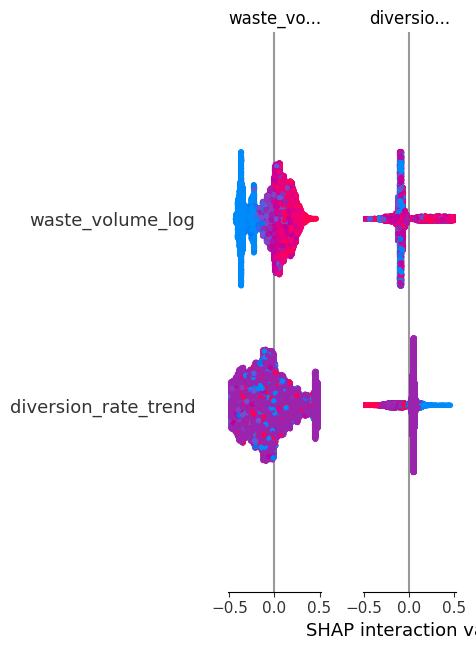

Saved.


In [9]:
import matplotlib.pyplot as plt

# Check shape and use correct indexing
print("shap_values type:", type(shap_values))
print("shap_values length:", len(shap_values))
print("X_test shape:", X_test.shape)

# Fix: use the full shap_values array
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('../src/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")